# CNN Predict — Event Dependence by Climate-Index Phase

Analyses the relationship between ENSO / IPO / Arctic SST phase and the
probability of (1) CNN-predicted true-positive slowdowns and (2) all
slowdowns.  Statistics include chi-squared / Fisher exact tests, bootstrap
confidence intervals, variance explained by phase, and logistic regression
odds ratios.

**Prerequisites**
- `scripts/03_cesm2le_tvt_splits.py` — TVT splits **and** `--climate-indices-only`
- `scripts/04_cesm2le_cnn_train.py` — train CNN models
- `scripts/06_cnn_predict_cesm2le.py` — precompute and save predictions

**Set `N_SPLITS` and `N_SEEDS` to match the values used during training, then Run All.**

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2_contingency, fisher_exact, norm
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from configs import paths
from src.cnn.splits import load_tvt_split
from src.cnn.model  import METRIC_NAMES

# Standardize figure appearance for publication
plt.rcParams.update({
    'font.size': 14*5,
    'axes.titlesize': 16*5,
    'axes.labelsize': 14*5,
    'xtick.labelsize': 12*5,
    'ytick.labelsize': 12*5,
    'legend.fontsize': 12*5,
})


2026-04-16 12:04:33.138823: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 12:04:33.141427: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-16 12:04:33.190430: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-16 12:04:33.190472: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-16 12:04:33.190509: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Config

In [2]:
# How many splits / seeds were trained
N_SPLITS  = 9          # max 9
N_SEEDS   = 5          # random seeds per split
BASE_SEED = 42

# Dataset
BLOCK_SIZE = 10        # ensemble members per TVT block
START_YEAR = 1990      # first year in the loaded splits

METRICS_DIR     = paths.RESULTS_DIR / 'metrics'
PREDICTIONS_DIR = paths.RESULTS_DIR / 'predictions' / 'cesm2le'

## Load loop
Loads TVT splits (for labels and SST arrays), **precomputed CNN predictions**,
and **LRP attributions** for all splits × seeds.

> **Note:** Model inference is no longer performed here. Predictions are loaded from
> files produced by `scripts/06_cnn_predict_cesm2le.py`.


In [3]:
results = {}

for split_idx in range(N_SPLITS):
    print(f'\n{chr(9472)*60}')
    print(f'Split {split_idx}')
    print(f'{chr(9472)*60}')

    # TVT split (for labels and SST arrays)
    split_path = paths.tvt_split_path(split_idx)
    if not split_path.exists():
        raise FileNotFoundError(
            f'TVT split not found: {split_path}\n'
            f'Run scripts/03_cesm2le_tvt_splits.py first.'
        )
    split = load_tvt_split(split_path)

    y_tr = split['slow_tr']
    y_va = split['slow_va']
    y_te = split['slow_te']
    y_true = {'train': y_tr, 'val': y_va, 'test': y_te}

    print(f'  Train: ({len(y_tr)},)  prevalence={y_tr.mean():.3f}')
    print(f'  Val  : ({len(y_va)},)  prevalence={y_va.mean():.3f}')
    print(f'  Test : ({len(y_te)},)  prevalence={y_te.mean():.3f}')

    y_scores_runs = []
    lrp_data      = []
    lat_shared    = None
    lon_shared    = None

    for run_idx in range(N_SEEDS):
        print(f'  seed {BASE_SEED + run_idx}: ', end='', flush=True)

        # Load precomputed predictions
        pred_path = PREDICTIONS_DIR / f'cnn_prediction_cesm2le_M{split_idx}_{run_idx}.nc'
        if not pred_path.exists():
            raise FileNotFoundError(
                f'Prediction file not found: {pred_path}\n'
                f'Run scripts/06_cnn_predict_cesm2le.py first.'
            )
        with xr.open_dataset(pred_path) as ds_pred:
            y_scores_runs.append({
                'train': ds_pred['y_prob_train'].values,
                'val':   ds_pred['y_prob_val'].values,
                'test':  ds_pred['y_prob_test'].values,
            })
        print('predictions \u2713', end='  ', flush=True)

        # ── LRP attributions ──────────────────────────────────────────────
        lrp_path = paths.attribution_path(split_idx, run_idx)
        if lrp_path.exists():
            lrp_ds   = xr.open_dataset(lrp_path)
            lrp_raw  = lrp_ds['lrp_attributions'].values
            lat_1d   = lrp_ds['lat'].values
            lon_1d   = lrp_ds['lon'].values
            lrp_ds.close()
            lrp_flat = lrp_raw.reshape(-1, lrp_raw.shape[2], lrp_raw.shape[3])
            lrp_data.append({'lrp_flat': lrp_flat})
            if lat_shared is None:
                lat_shared = lat_1d
                lon_shared = lon_1d
            print('LRP \u2713')
        else:
            lrp_data.append(None)
            print(f'(LRP not found: {lrp_path})')

    results[split_idx] = {
        'y_scores_runs': y_scores_runs,
        'y_true':        y_true,
        'n_tr':          len(y_tr),
        'lrp_data':      lrp_data,
        'sst_tr':        split['sst_tr'],
        'lat':           lat_shared,
        'lon':           lon_shared,
    }

print('\nLoading complete.')


## Load climate indices

In [4]:
# Load split-aligned climate indices
for split_idx in range(N_SPLITS):
    idx_path = paths.TVT_SPLITS_DIR / f'cesm2le_climate_indices_split{split_idx}.nc'
    if not idx_path.exists():
        raise FileNotFoundError(
            f'Climate index split not found: {idx_path}\n'
            f'Run scripts/03_cesm2le_tvt_splits.py --climate-indices-only first.'
        )
    with xr.open_dataset(idx_path) as ds_idx:
        for vname in ds_idx.data_vars:
            results[split_idx][vname] = ds_idx[vname].values
print('Climate indices loaded for all splits.')

# Phase definitions
# ENSO: +/-0.4 std (3 phases)
ENSO_PHASES  = (-1, 0, 1)
ENSO_LABELS  = ('La Ni\u00f1a', 'Neutral', 'El Ni\u00f1o')

def enso_phase_labels(idx_vals):
    'Assign ENSO phase labels: -1/0/+1 based on +/-0.4 threshold.'
    out = np.zeros(len(idx_vals), dtype=int)
    out[idx_vals <= -0.4] = -1
    out[idx_vals >=  0.4] =  1
    return out

# IPO: sign-based (2 phases)
IPO_PHASES  = (-1, 1)
IPO_LABELS  = ('\u2212', '+')

def ipo_phase_labels(idx_vals):
    'Assign IPO phase labels: -1/+1 based on sign.'
    return np.where(idx_vals <= 0, -1, 1).astype(int)

# Arctic SST: +/-1.0 std (3 phases)
ARCTIC_PHASES  = (-1, 0, 1)
ARCTIC_LABELS  = ('\u2212', 'Neutral', '+')

def arctic_phase_labels(idx_vals):
    'Assign Arctic SST phase labels: -1/0/+1 based on +/-1.0 threshold.'
    out = np.zeros(len(idx_vals), dtype=int)
    out[idx_vals <= -1.0] = -1
    out[idx_vals >=  1.0] =  1
    return out

Climate indices loaded for all splits.


## Statistical helper functions

In [5]:
def event_dependence_by_phase(phase_labels, event_bool, phases=(-1, 0, 1), B=5000):
    'P(event | phase) with chi2/Fisher test and bootstrap CIs.'
    phase_labels = np.asarray(phase_labels)
    event_bool   = np.asarray(event_bool, dtype=bool)

    probs, counts, n_phase, ci_lo, ci_hi = {}, {}, {}, {}, {}

    for ph in phases:
        sel = phase_labels == ph
        n   = sel.sum()
        n_phase[ph] = int(n)
        k = event_bool[sel].sum()
        counts[ph] = int(k)
        probs[ph]  = k / n if n > 0 else np.nan

        rng   = np.random.default_rng(42)
        boots = np.empty(B)
        sub   = event_bool[sel].astype(float)
        for b in range(B):
            boots[b] = rng.choice(sub, size=n, replace=True).mean()
        ci_lo[ph], ci_hi[ph] = np.percentile(boots, [2.5, 97.5])

    table = np.array([[counts.get(ph, 0), n_phase.get(ph, 0) - counts.get(ph, 0)]
                       for ph in phases])
    if table.shape[0] >= 2 and table.min() >= 0:
        chi2_p = chi2_contingency(table)[1]
        fisher_p = fisher_exact(table)[1] if table.shape[0] == 2 else np.nan
    else:
        chi2_p = fisher_p = np.nan

    return dict(probs=probs, counts=counts, n_phase=n_phase,
                ci_lo=ci_lo, ci_hi=ci_hi, chi2_p=chi2_p, fisher_p=fisher_p)


def event_dependence_by_phase_multiseed(phase_labels, event_masks_seeds,
                                         phases=(-1, 0, 1), B=5000):
    'P(event | phase) with nested bootstrap over seeds and time.'
    phase_labels = np.asarray(phase_labels)
    n_seeds = len(event_masks_seeds)
    rng = np.random.default_rng(42)

    seed_probs = {ph: [] for ph in phases}
    for mask_s in event_masks_seeds:
        mask_s = np.asarray(mask_s, dtype=bool)
        for ph in phases:
            sel = phase_labels == ph
            n   = sel.sum()
            seed_probs[ph].append(mask_s[sel].mean() if n > 0 else np.nan)

    probs_mean = {ph: np.nanmean(seed_probs[ph]) for ph in phases}

    boot_probs = {ph: np.empty(B) for ph in phases}
    for b in range(B):
        seed_ids = rng.choice(n_seeds, size=n_seeds, replace=True)
        for ph in phases:
            sel = phase_labels == ph
            n = sel.sum()
            if n == 0:
                boot_probs[ph][b] = np.nan
                continue
            vals = []
            for si in seed_ids:
                sub = event_masks_seeds[si][sel].astype(float)
                vals.append(rng.choice(sub, size=n, replace=True).mean())
            boot_probs[ph][b] = np.nanmean(vals)

    ci_lo = {ph: np.nanpercentile(boot_probs[ph], 2.5)  for ph in phases}
    ci_hi = {ph: np.nanpercentile(boot_probs[ph], 97.5) for ph in phases}

    table = []
    for ph in phases:
        n = (phase_labels == ph).sum()
        k = int(round(probs_mean[ph] * n))
        table.append([k, n - k])
    table = np.array(table)
    chi2_p = chi2_contingency(table)[1] if table.shape[0] >= 2 else np.nan

    return dict(probs_mean=probs_mean, ci_lo=ci_lo, ci_hi=ci_hi, chi2_p=chi2_p)


def variance_explained_by_phase(phase_labels, event_bool, phases=(-1, 0, 1), B=5000):
    'Between-phase variance / total variance of binary event, with bootstrap CI.'
    phase_labels = np.asarray(phase_labels)
    event_bool   = np.asarray(event_bool, dtype=float)
    grand_mean = event_bool.mean()
    total_var  = event_bool.var()
    if total_var == 0:
        return dict(ve=np.nan, ci_lo=np.nan, ci_hi=np.nan)

    between = 0.0
    for ph in phases:
        sel = phase_labels == ph
        n_ph = sel.sum()
        if n_ph == 0:
            continue
        between += n_ph * (event_bool[sel].mean() - grand_mean) ** 2
    between /= len(event_bool)
    ve = between / total_var

    rng = np.random.default_rng(42)
    boots = np.empty(B)
    n = len(event_bool)
    for b in range(B):
        idx = rng.choice(n, size=n, replace=True)
        eb = event_bool[idx]
        pl = phase_labels[idx]
        gm = eb.mean()
        tv = eb.var()
        if tv == 0:
            boots[b] = np.nan
            continue
        bw = 0.0
        for ph in phases:
            sel_b = pl == ph
            n_ph = sel_b.sum()
            if n_ph == 0:
                continue
            bw += n_ph * (eb[sel_b].mean() - gm) ** 2
        bw /= n
        boots[b] = bw / tv
    ci_lo, ci_hi = np.nanpercentile(boots, [2.5, 97.5])

    return dict(ve=ve, ci_lo=ci_lo, ci_hi=ci_hi)


def logit_or_r2(phase_labels, event_bool, phases=(-1, 0, 1)):
    'Logistic regression: odds ratio, McFadden R-squared, Wald CI.'
    X = phase_labels.reshape(-1, 1).astype(float)
    y = np.asarray(event_bool, dtype=int)

    if len(np.unique(y)) < 2:
        return dict(odds_ratio=np.nan, or_ci_lo=np.nan, or_ci_hi=np.nan, mcfadden_r2=np.nan)

    model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
    model.fit(X, y)
    coef = model.coef_[0, 0]
    odds_ratio = np.exp(coef)

    # McFadden R-squared
    prob_pred = model.predict_proba(X)
    ll_model = np.sum(y * np.log(prob_pred[:, 1] + 1e-12) +
                      (1 - y) * np.log(prob_pred[:, 0] + 1e-12))
    p0 = y.mean()
    ll_null = np.sum(y * np.log(p0 + 1e-12) + (1 - y) * np.log(1 - p0 + 1e-12))
    mcfadden_r2 = 1 - ll_model / ll_null if ll_null != 0 else np.nan

    # Wald CI for odds ratio
    probs = prob_pred[:, 1]
    W = np.diag(probs * (1 - probs))
    try:
        Xd = np.hstack([np.ones((len(X), 1)), X])
        XtWX_inv = np.linalg.inv(Xd.T @ W @ Xd)
        se = np.sqrt(XtWX_inv[1, 1])
    except np.linalg.LinAlgError:
        se = np.nan
    or_ci_lo = np.exp(coef - 1.96 * se) if np.isfinite(se) else np.nan
    or_ci_hi = np.exp(coef + 1.96 * se) if np.isfinite(se) else np.nan

    return dict(odds_ratio=odds_ratio, or_ci_lo=or_ci_lo, or_ci_hi=or_ci_hi,
                mcfadden_r2=mcfadden_r2)

## Compute scenario masks

For each split and seed, compute TP / all-slowdown masks on **training** data.

In [6]:
for split_idx in range(N_SPLITS):
    res = results[split_idx]
    y_t = res['y_true']['train']

    tp_masks_seeds = []   # one per seed
    slow_mask      = (y_t == 1)   # all actual slowdowns

    for run_idx in range(N_SEEDS):
        y_s = res['y_scores_runs'][run_idx]['train']
        prec, rec, thr = precision_recall_curve(y_t, y_s)
        thr_best = thr[np.argmin(np.abs(prec[:-1] - rec[:-1]))] if thr.size > 0 else 0.5
        y_pred = (y_s >= thr_best).astype(int)
        tp_masks_seeds.append((y_pred == 1) & (y_t == 1))

    res['tp_masks_seeds'] = tp_masks_seeds
    res['slow_mask']      = slow_mask

print('Scenario masks computed for all splits and seeds.')

Scenario masks computed for all splits and seeds.


## Event-dependence plotting function

In [7]:
def plot_event_dependence(index_key_tr, index_name, phase_labeler,
                         phases, phase_names, figsize=(15*5, 10*5)):
    '''Event dependence analysis for one climate index.
    Layout: (a) bar chart (full left column),
            (b) composition table (upper right),
            (c) statistics table (lower right).
    '''
    n_phases = len(phases)

    # Gather across all splits
    all_phase_labels = []
    all_slow_masks   = []
    all_tp_seeds     = []

    for si in range(N_SPLITS):
        res = results[si]
        idx_vals = res[index_key_tr]
        plabels  = phase_labeler(idx_vals)

        all_phase_labels.append(plabels)
        all_slow_masks.append(res['slow_mask'])
        all_tp_seeds.append(res['tp_masks_seeds'])

    # Concatenate across splits
    phase_cat = np.concatenate(all_phase_labels)
    slow_cat  = np.concatenate(all_slow_masks)

    # TP: concatenate per-seed across splits
    tp_cat_seeds = []
    for seed_idx in range(N_SEEDS):
        tp_cat_seeds.append(np.concatenate([
            all_tp_seeds[si][seed_idx] for si in range(N_SPLITS)
        ]))

    # Statistics
    res_slow = event_dependence_by_phase(phase_cat, slow_cat, phases=phases, B=5000)
    res_tp = event_dependence_by_phase_multiseed(
        phase_cat, tp_cat_seeds, phases=phases, B=5000
    )
    ve_slow = variance_explained_by_phase(phase_cat, slow_cat, phases=phases, B=5000)
    tp_avg = np.mean(np.stack(tp_cat_seeds, axis=0), axis=0) >= 0.5
    ve_tp = variance_explained_by_phase(phase_cat, tp_avg, phases=phases, B=5000)
    lr_slow = logit_or_r2(phase_cat, slow_cat, phases=phases)
    lr_tp = logit_or_r2(phase_cat, tp_avg, phases=phases)

    # ------------------------------------------------------------------
    # Figure: (a) bar chart (left column, full height),
    #         (b) composition table (upper right),
    #         (c) statistics table (lower right)
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 2, width_ratios=[1.2, 1], height_ratios=[1, 1],
                          wspace=0.15, hspace=0.25)

    # ── Panel (a): bar chart spanning both rows of left column ────────
    ax1 = fig.add_subplot(gs[:, 0])

    x = np.arange(n_phases)
    width = 0.35

    slow_probs = [res_slow['probs'][ph] for ph in phases]
    slow_lo    = [res_slow['probs'][ph] - res_slow['ci_lo'][ph] for ph in phases]
    slow_hi    = [res_slow['ci_hi'][ph] - res_slow['probs'][ph] for ph in phases]

    tp_probs   = [res_tp['probs_mean'][ph] for ph in phases]
    tp_lo      = [res_tp['probs_mean'][ph] - res_tp['ci_lo'][ph] for ph in phases]
    tp_hi      = [res_tp['ci_hi'][ph] - res_tp['probs_mean'][ph] for ph in phases]

    ax1.bar(x - width / 2, slow_probs, width, yerr=[slow_lo, slow_hi],
            color='gray', alpha=0.6, edgecolor='black', capsize=3*5,
            label='All slowdowns')
    ax1.bar(x + width / 2, tp_probs, width, yerr=[tp_lo, tp_hi],
            color='steelblue', alpha=0.7, edgecolor='black', capsize=3*5,
            label='TP slowdowns')
    ax1.set_xticks(x)
    ax1.set_xticklabels(phase_names)
    ax1.set_ylabel('P(event | phase)')
    ax1.set_title('(a)')
    ax1.legend()
    ax1.set_ylim(0, min(1.0, max(slow_probs + tp_probs) * 1.5 + 0.05))

    # ── Panel (b): composition TABLE (upper right) ────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.axis('off')
    col_labels = ['n', '#slow', '#TP', 'P(slow)', 'P(TP)']
    rows = []
    for ph in phases:
        in_phase = (phase_cat == ph)
        n_ph   = int(in_phase.sum())
        n_slow = int(slow_cat[in_phase].sum())
        p_slow = res_slow['probs'][ph]
        p_tp   = res_tp['probs_mean'][ph]
        n_tp = int(round(np.mean([
            int(tp_seed[in_phase].sum()) for tp_seed in tp_cat_seeds
        ])))
        rows.append([
            f'{n_ph:d}', f'{n_slow:d}', f'{n_tp:d}',
            f'{p_slow:.3f}', f'{p_tp:.3f}',
        ])

    tbl = ax2.table(
        cellText=rows,
        rowLabels=list(phase_names),
        colLabels=col_labels,
        cellLoc='center',
        rowLoc='center',
        loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12*5)
    tbl.scale(1.0, 2.5)

    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#e8eef5')
        elif c == -1:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f3f3f3')

    ax2.set_title('(b)')

    # ── Panel (c): statistics TABLE (lower right) ─────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')

    stat_col_labels = ['Metric', 'All slowdowns', 'TP slowdowns']
    stat_rows = [
        ['chi2 p',
         f'{res_slow["chi2_p"]:.4f}',
         f'{res_tp["chi2_p"]:.4f}'],
        ['VE',
         f'{ve_slow["ve"]:.3f} [{ve_slow["ci_lo"]:.3f}, {ve_slow["ci_hi"]:.3f}]',
         f'{ve_tp["ve"]:.3f} [{ve_tp["ci_lo"]:.3f}, {ve_tp["ci_hi"]:.3f}]'],
        ['OR',
         f'{lr_slow["odds_ratio"]:.3f} [{lr_slow["or_ci_lo"]:.3f}, {lr_slow["or_ci_hi"]:.3f}]',
         f'{lr_tp["odds_ratio"]:.3f} [{lr_tp["or_ci_lo"]:.3f}, {lr_tp["or_ci_hi"]:.3f}]'],
        ['McFadden R²',
         f'{lr_slow["mcfadden_r2"]:.4f}',
         f'{lr_tp["mcfadden_r2"]:.4f}'],
    ]
    fp = res_slow.get('fisher_p', np.nan)
    if np.isfinite(fp):
        stat_rows.insert(1, ['Fisher p', f'{fp:.4f}', '—'])

    tbl2 = ax3.table(
        cellText=stat_rows,
        colLabels=stat_col_labels,
        cellLoc='center',
        loc='center',
    )
    tbl2.auto_set_font_size(False)
    tbl2.set_fontsize(12*5)
    tbl2.scale(1.0, 2.5)

    for (r, c), cell in tbl2.get_celld().items():
        if r == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#e8eef5')

    ax3.set_title('(c)')

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f'\n{"="*60}')
    print(f'{index_name} Summary')
    print(f'{"="*60}')
    print(f'All slowdowns: chi2 p = {res_slow["chi2_p"]:.4f}')
    print(f'  VE = {ve_slow["ve"]:.3f} [{ve_slow["ci_lo"]:.3f}, {ve_slow["ci_hi"]:.3f}]')
    print(f'  OR = {lr_slow["odds_ratio"]:.3f} [{lr_slow["or_ci_lo"]:.3f}, {lr_slow["or_ci_hi"]:.3f}]')
    print(f'TP slowdowns: chi2 p = {res_tp["chi2_p"]:.4f}')
    print(f'  VE = {ve_tp["ve"]:.3f} [{ve_tp["ci_lo"]:.3f}, {ve_tp["ci_hi"]:.3f}]')
    print(f'  OR = {lr_tp["odds_ratio"]:.3f} [{lr_tp["or_ci_lo"]:.3f}, {lr_tp["or_ci_hi"]:.3f}]')
    print(f'{"="*60}\n')


---
## Event dependence by climate-index phase

Each call produces an overlay bar chart (gray = all slowdowns, blue = TP slowdowns)
with bootstrap CIs, sample counts, and a statistics summary including chi-squared,
Fisher exact, variance explained, and logistic regression odds ratio.

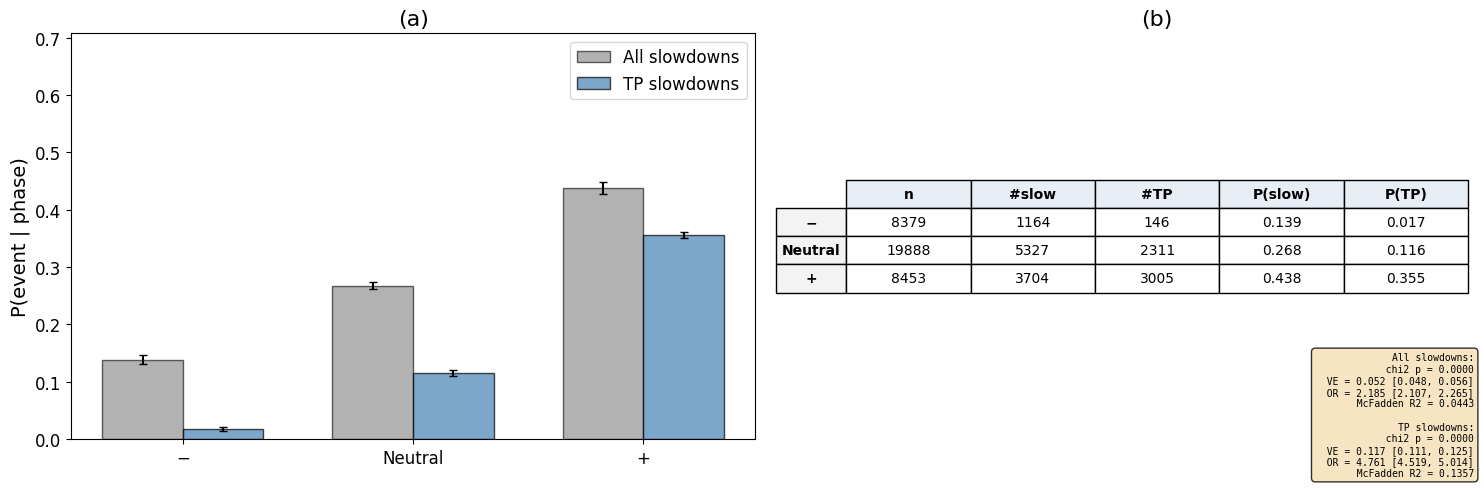


Arctic SST Summary
All slowdowns:
  chi2 p = 0.0000
  VE = 0.052 [0.048, 0.056]
  OR = 2.185 [2.107, 2.265]
  McFadden R2 = 0.0443

TP slowdowns:
  chi2 p = 0.0000
  VE = 0.117 [0.111, 0.125]
  OR = 4.761 [4.519, 5.014]
  McFadden R2 = 0.1357



In [8]:
plot_event_dependence(
    index_key_tr  = 'arctic_tr',
    index_name    = 'Arctic SST',
    phase_labeler = arctic_phase_labels,
    phases        = ARCTIC_PHASES,
    phase_names   = ARCTIC_LABELS,
)

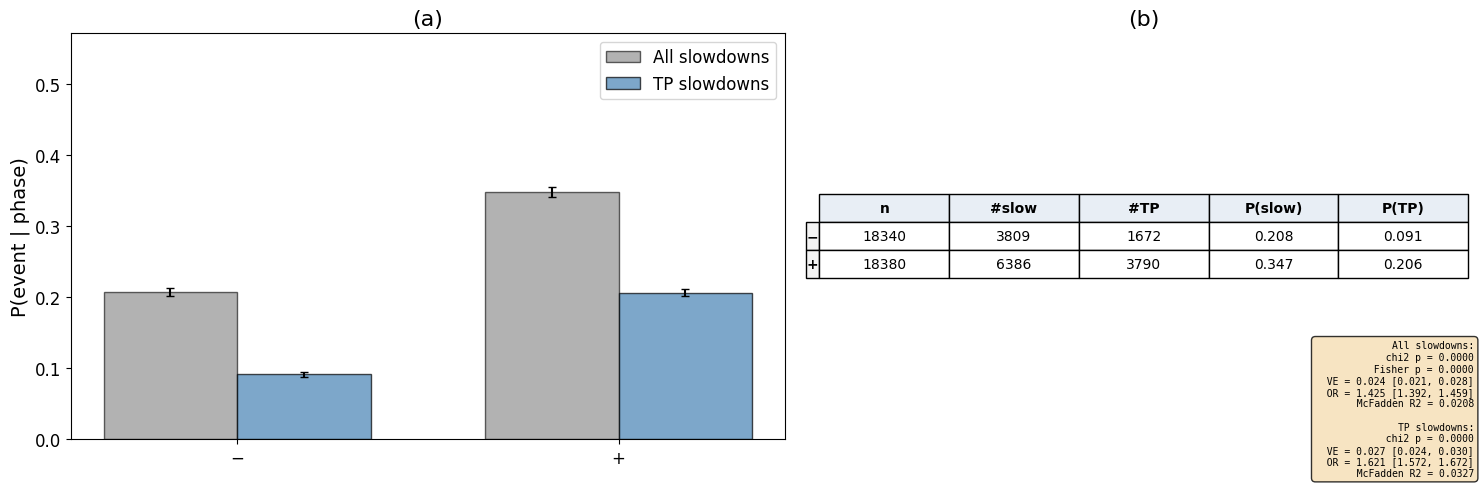


IPO Summary
All slowdowns:
  chi2 p = 0.0000
  Fisher p = 0.0000
  VE = 0.024 [0.021, 0.028]
  OR = 1.425 [1.392, 1.459]
  McFadden R2 = 0.0208

TP slowdowns:
  chi2 p = 0.0000
  VE = 0.027 [0.024, 0.030]
  OR = 1.621 [1.572, 1.672]
  McFadden R2 = 0.0327



In [9]:
plot_event_dependence(
    index_key_tr  = 'ipo_tr',
    index_name    = 'IPO',
    phase_labeler = ipo_phase_labels,
    phases        = IPO_PHASES,
    phase_names   = IPO_LABELS,
)

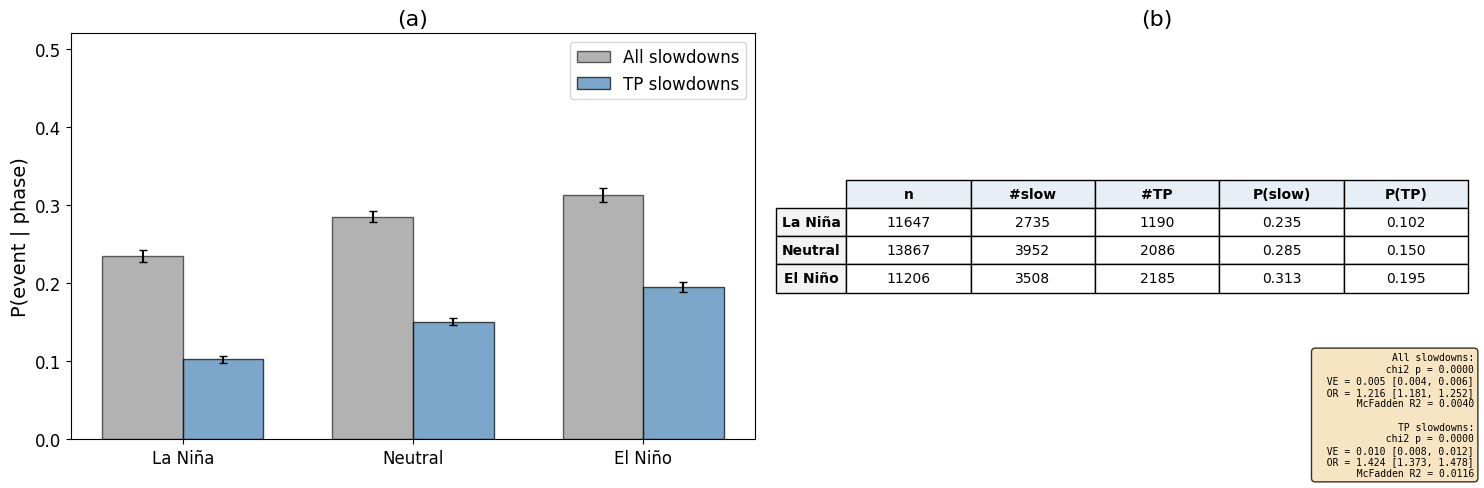


Nino3.4 (ENSO) Summary
All slowdowns:
  chi2 p = 0.0000
  VE = 0.005 [0.004, 0.006]
  OR = 1.216 [1.181, 1.252]
  McFadden R2 = 0.0040

TP slowdowns:
  chi2 p = 0.0000
  VE = 0.010 [0.008, 0.012]
  OR = 1.424 [1.373, 1.478]
  McFadden R2 = 0.0116



In [10]:
plot_event_dependence(
    index_key_tr  = 'nino34_tr',
    index_name    = 'Nino3.4 (ENSO)',
    phase_labeler = enso_phase_labels,
    phases        = ENSO_PHASES,
    phase_names   = ENSO_LABELS,
)

---
## Combined summary figure

Single figure with 3 subpanels (one per index) showing P(event | phase)
for both all slowdowns and TP slowdowns.

In [11]:
INDEX_CONFIGS = [
    ('arctic_tr', 'Arctic SST', arctic_phase_labels, ARCTIC_PHASES, ARCTIC_LABELS),
    ('ipo_tr',    'IPO',        ipo_phase_labels,    IPO_PHASES,    IPO_LABELS),
    ('nino34_tr', 'Nino3.4',    enso_phase_labels,   ENSO_PHASES,   ENSO_LABELS),
]

fig, axes = plt.subplots(1, 3, figsize=(18*5, 5*5), sharey=True)

panel_labels = ['(a)', '(b)', '(c)']

for ax, (key, name, labeler, phases, pnames), plabel in zip(axes, INDEX_CONFIGS, panel_labels):
    # Pool across splits
    phase_cat = np.concatenate([labeler(results[si][key]) for si in range(N_SPLITS)])
    slow_cat  = np.concatenate([results[si]['slow_mask'] for si in range(N_SPLITS)])
    tp_seeds  = [np.concatenate([results[si]['tp_masks_seeds'][ri]
                                  for si in range(N_SPLITS)])
                 for ri in range(N_SEEDS)]

    res_s = event_dependence_by_phase(phase_cat, slow_cat, phases=phases, B=5000)
    res_t = event_dependence_by_phase_multiseed(phase_cat, tp_seeds, phases=phases, B=5000)

    # Variance explained
    ve_slow = variance_explained_by_phase(phase_cat, slow_cat, phases=phases, B=5000)
    tp_avg  = np.mean(np.stack(tp_seeds, axis=0), axis=0) >= 0.5
    ve_tp   = variance_explained_by_phase(phase_cat, tp_avg, phases=phases, B=5000)

    n_ph = len(phases)
    x = np.arange(n_ph)
    w = 0.35

    sp = [res_s['probs'][ph] for ph in phases]
    s_lo = [res_s['probs'][ph] - res_s['ci_lo'][ph] for ph in phases]
    s_hi = [res_s['ci_hi'][ph] - res_s['probs'][ph] for ph in phases]

    tp = [res_t['probs_mean'][ph] for ph in phases]
    t_lo = [res_t['probs_mean'][ph] - res_t['ci_lo'][ph] for ph in phases]
    t_hi = [res_t['ci_hi'][ph] - res_t['probs_mean'][ph] for ph in phases]

    ax.bar(x - w/2, sp, w, yerr=[s_lo, s_hi], color='gray', alpha=0.6,
           edgecolor='black', capsize=3*5, label='All slowdowns')
    ax.bar(x + w/2, tp, w, yerr=[t_lo, t_hi], color='steelblue', alpha=0.7,
           edgecolor='black', capsize=3*5, label='TP slowdowns')

    ax.set_xticks(x)
    ax.set_xticklabels(pnames)
    ax.set_title(plabel)

    # Annotate VE (not chi-square p-values)
    ax.text(0.02, 0.98,
            f'VE = {ve_slow["ve"]:.3f} [{ve_slow["ci_lo"]:.3f}, {ve_slow["ci_hi"]:.3f}] (slow)\n'
            f'VE = {ve_tp["ve"]:.3f} [{ve_tp["ci_lo"]:.3f}, {ve_tp["ci_hi"]:.3f}] (TP)',
            transform=ax.transAxes, fontsize=12*5, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))

axes[0].set_ylabel('P(event | phase)')
axes[0].legend()

plt.tight_layout()
plt.show()


In [12]:
# Separate figures: (1) all slowdowns only, (2) TP slowdowns only
# Reuses INDEX_CONFIGS from the cell above.

# Pre-compute stats for all three indices
_cached = []
for key, name, labeler, phases, pnames in INDEX_CONFIGS:
    phase_cat = np.concatenate([labeler(results[si][key]) for si in range(N_SPLITS)])
    slow_cat  = np.concatenate([results[si]['slow_mask'] for si in range(N_SPLITS)])
    tp_seeds  = [np.concatenate([results[si]['tp_masks_seeds'][ri]
                                  for si in range(N_SPLITS)])
                 for ri in range(N_SEEDS)]

    res_s = event_dependence_by_phase(phase_cat, slow_cat, phases=phases, B=5000)
    res_t = event_dependence_by_phase_multiseed(phase_cat, tp_seeds, phases=phases, B=5000)

    ve_slow = variance_explained_by_phase(phase_cat, slow_cat, phases=phases, B=5000)
    tp_avg  = np.mean(np.stack(tp_seeds, axis=0), axis=0) >= 0.5
    ve_tp   = variance_explained_by_phase(phase_cat, tp_avg, phases=phases, B=5000)

    _cached.append(dict(
        name=name, phases=phases, pnames=pnames,
        res_s=res_s, res_t=res_t, ve_slow=ve_slow, ve_tp=ve_tp,
    ))

panel_labels = ['(a)', '(b)', '(c)']

# --- Figure 1: All slowdowns (grey bars) ---
fig1, axes1 = plt.subplots(1, 3, figsize=(18*5, 5*5), sharey=True)

for ax, d, plabel in zip(axes1, _cached, panel_labels):
    phases = d['phases']
    n_ph = len(phases)
    x = np.arange(n_ph)

    sp   = [d['res_s']['probs'][ph]                       for ph in phases]
    s_lo = [d['res_s']['probs'][ph] - d['res_s']['ci_lo'][ph] for ph in phases]
    s_hi = [d['res_s']['ci_hi'][ph] - d['res_s']['probs'][ph] for ph in phases]

    ax.bar(x, sp, 0.5, yerr=[s_lo, s_hi], color='gray', alpha=0.6,
           edgecolor='black', capsize=4*5)
    ax.set_xticks(x)
    ax.set_xticklabels(d['pnames'])
    ax.set_title(plabel)

    ve = d['ve_slow']
    ax.text(0.02, 0.98,
            f'VE = {ve["ve"]:.3f} [{ve["ci_lo"]:.3f}, {ve["ci_hi"]:.3f}]',
            transform=ax.transAxes, fontsize=12*5, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))

axes1[0].set_ylabel('P(slowdown | phase)')
plt.tight_layout()
plt.show()

# --- Figure 2: TP slowdowns (blue bars) ---
fig2, axes2 = plt.subplots(1, 3, figsize=(18*5, 5*5), sharey=True)

for ax, d, plabel in zip(axes2, _cached, panel_labels):
    phases = d['phases']
    n_ph = len(phases)
    x = np.arange(n_ph)

    tp   = [d['res_t']['probs_mean'][ph]                       for ph in phases]
    t_lo = [d['res_t']['probs_mean'][ph] - d['res_t']['ci_lo'][ph] for ph in phases]
    t_hi = [d['res_t']['ci_hi'][ph] - d['res_t']['probs_mean'][ph] for ph in phases]

    ax.bar(x, tp, 0.5, yerr=[t_lo, t_hi], color='steelblue', alpha=0.7,
           edgecolor='black', capsize=4*5)
    ax.set_xticks(x)
    ax.set_xticklabels(d['pnames'])
    ax.set_title(plabel)

    ve = d['ve_tp']
    ax.text(0.02, 0.98,
            f'VE = {ve["ve"]:.3f} [{ve["ci_lo"]:.3f}, {ve["ci_hi"]:.3f}]',
            transform=ax.transAxes, fontsize=12*5, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))

axes2[0].set_ylabel('P(TP slowdown | phase)')
plt.tight_layout()
plt.show()


---
## Composite Maps (from model performance analysis)

For each selected scenario (TP / FP / TN / FN):
- **(a)** Mean JJA SST input over all scenario samples (land masked to NaN)
- **(b)** Mean LRP attribution over all scenario samples

Composites are computed per split × seed first, then averaged across all splits × seeds.

> **Note:** LRP must have been computed with `scripts/05_cesm2le_lrp.py`.
> Splits/seeds missing LRP files are automatically skipped.


---
## Composite Maps

For each selected scenario (TP / FP / TN / FN):
- **(a)** Mean JJA SST input over all scenario samples (land masked to NaN)
- **(b)** Mean LRP attribution over all scenario samples

Composites are computed per split × seed first, then averaged across all splits × seeds.

> **Note:** LRP must have been computed with `scripts/05_cesm2le_lrp.py`. Splits/seeds missing LRP files are automatically skipped.

In [ ]:
# ── Toggle scenarios to plot ──────────────────────────────────────────────────
SHOW_TP = True
SHOW_FP = False
SHOW_TN = False
SHOW_FN = False

In [ ]:
SCENARIO_FLAGS = {'TP': SHOW_TP, 'FP': SHOW_FP, 'TN': SHOW_TN, 'FN': SHOW_FN}
ACTIVE_SCENARIOS = [k for k, v in SCENARIO_FLAGS.items() if v]

for scenario_name in ACTIVE_SCENARIOS:

    sst_per_sr = []
    lrp_per_sr = []
    lat_plot   = None
    lon_plot   = None

    for split_idx in range(N_SPLITS):
        res    = results[split_idx]
        sst_tr = res['sst_tr']   # (n_tr, nx, ny)

        for run_idx in range(N_SEEDS):
            lrp_info = res['lrp_data'][run_idx]
            if lrp_info is None:
                continue   # LRP not available for this split/seed

            y_s = res['y_scores_runs'][run_idx]['train']
            y_t = res['y_true']['train']

            # ── threshold ────────────────────────────────────────────────────
            prec, rec, thr = precision_recall_curve(y_t, y_s)
            thr_best = thr[np.argmin(np.abs(prec[:-1] - rec[:-1]))] if thr.size > 0 else 0.5
            y_pred   = (y_s >= thr_best).astype(int)

            # ── scenario mask ─────────────────────────────────────────────────
            if scenario_name == 'TP':
                mask = (y_pred == 1) & (y_t == 1)
            elif scenario_name == 'FP':
                mask = (y_pred == 1) & (y_t == 0)
            elif scenario_name == 'TN':
                mask = (y_pred == 0) & (y_t == 0)
            else:   # FN
                mask = (y_pred == 0) & (y_t == 1)

            # ── align LRP with training data (LRP may have fewer samples) ────
            lrp_flat = lrp_info['lrp_flat']   # (n_lrp, nx, ny)
            n_lrp    = lrp_flat.shape[0]
            mask_lrp = mask[:n_lrp]
            sst_lrp  = sst_tr[:n_lrp]         # (n_lrp, nx, ny)

            if mask_lrp.sum() == 0:
                continue

            # ── SST composite — land fill (-10) → NaN ────────────────────────
            sst_masked = sst_lrp.astype(float).copy()
            sst_masked[sst_masked < -5] = np.nan
            sst_mean = np.nanmean(sst_masked[mask_lrp], axis=0)   # (nx, ny)

            # ── LRP composite ────────────────────────────────────────────────
            lrp_mean = np.nanmean(lrp_flat[mask_lrp], axis=0)        # (nx, ny)

            sst_per_sr.append(sst_mean)
            lrp_per_sr.append(lrp_mean)

            if lat_plot is None:
                lat_plot = res['lat']
                lon_plot = res['lon']

    if len(sst_per_sr) == 0:
        print(f'{scenario_name}: no samples found across any split/seed — skipping.')
        continue

    n_sr      = len(sst_per_sr)
    sst_grand = np.nanmean(np.stack(sst_per_sr, axis=0), axis=0)  # (nx, ny)
    lrp_grand = np.nanmean(np.stack(lrp_per_sr, axis=0), axis=0)  # (nx, ny)

    print(f'{scenario_name}: averaged over {n_sr} split×seed composites')

    # ── Normalize ensemble-mean maps (97th percentile) ────────────────────────
    sst_scale = np.nanpercentile(np.abs(sst_grand), 97)
    sst_grand = np.clip(sst_grand / (sst_scale + 1e-12), -1, 1)

    lrp_scale = np.nanpercentile(np.abs(lrp_grand), 97)
    lrp_grand = np.clip(lrp_grand / (lrp_scale + 1e-12), -1, 1)

    # ── Build 2-D lat/lon grid for plotting ───────────────────────────────────
    lon2d, lat2d = np.meshgrid(lon_plot, lat_plot)   # (nlat, nlon)

    # ── Figure ────────────────────────────────────────────────────────────────
    proj  = ccrs.PlateCarree(central_longitude=180)

    fig = plt.figure(figsize=(14*5, 5*5))
    ax_sst = fig.add_subplot(1, 2, 1, projection=proj)
    ax_lrp = fig.add_subplot(1, 2, 2, projection=proj)

    for ax, data, vmin, vmax, cmap, label_txt, panel_lbl in [
        (ax_sst, sst_grand, -1, 1, cmocean.cm.balance, 'SST (normalized)', '(a)'),
        (ax_lrp, lrp_grand, -1, 1, cmocean.cm.curl,    'Relevance (normalized)', '(b)'),
    ]:
        ax.set_global()
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
        ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

        im = ax.pcolormesh(
            lon2d, lat2d, data,
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            transform=ccrs.PlateCarree(),
            shading='auto',
            zorder=0,
        )
        plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04,
                     fraction=0.046, label=label_txt)
        ax.set_title(panel_lbl)

    plt.tight_layout()
    plt.show()

In [ ]:
from scipy.ndimage import gaussian_filter

def smooth_2d(data, sigma=0.5):
    """Gaussian smoothing that preserves NaNs."""
    mask = np.isnan(data)

    # Fill NaNs with 0 for filtering
    data_filled = np.where(mask, 0, data)

    # Smooth data and weights separately
    smooth_data = gaussian_filter(data_filled, sigma=sigma)
    smooth_weights = gaussian_filter((~mask).astype(float), sigma=sigma)

    # Avoid divide by zero
    with np.errstate(invalid='ignore'):
        result = smooth_data / smooth_weights

    result[mask] = np.nan
    return result

# Apply smoothing ONLY to panel (b)
lrp_smooth = smooth_2d(lrp_grand, sigma=1)


# ── Figure ────────────────────────────────────────────────────────────────
proj  = ccrs.PlateCarree(central_longitude=180)

fig = plt.figure(figsize=(14*5, 5*5))
ax_sst = fig.add_subplot(1, 2, 1, projection=proj)
ax_lrp = fig.add_subplot(1, 2, 2, projection=proj)

for ax, data, vmin, vmax, cmap, label_txt, panel_lbl in [
    (ax_sst, sst_grand, -1, 1, cmocean.cm.balance, 'SST (normalized)', '(a)'),
    (ax_lrp, lrp_smooth, -1, 1, cmocean.cm.curl,    'Relevance (normalized)', '(b)'),
]:
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6*3, zorder=2)
    ax.gridlines(draw_labels=False, linewidth=0.3*3, color='gray', alpha=0.5)

    im = ax.pcolormesh(
        lon2d, lat2d, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(),
        shading='auto',
        zorder=0,
    )
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04,
                    fraction=0.046, label=label_txt)
    ax.set_title(panel_lbl)

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# plotting options
# ------------------------------------------------------------------
LRP_POSITIVE_ONLY = True   # False = signed relevance, True = keep only positive
LRP_POSITIVE_CMAP = 'gnuplot2' #'magma'
LRP_SIGNED_CMAP   = cmocean.cm.curl

SCENARIO_FLAGS = {'TP': SHOW_TP, 'FP': SHOW_FP, 'TN': SHOW_TN, 'FN': SHOW_FN}
ACTIVE_SCENARIOS = [k for k, v in SCENARIO_FLAGS.items() if v]

for scenario_name in ACTIVE_SCENARIOS:

    sst_per_sr = []
    lrp_per_sr = []
    lat_plot   = None
    lon_plot   = None

    for split_idx in range(N_SPLITS):
        res    = results[split_idx]
        sst_tr = res['sst_tr']   # (n_tr, nx, ny)

        for run_idx in range(N_SEEDS):
            lrp_info = res['lrp_data'][run_idx]
            if lrp_info is None:
                continue

            y_s = res['y_scores_runs'][run_idx]['train']
            y_t = res['y_true']['train']

            # ── threshold ──────────────────────────────────────────────
            prec, rec, thr = precision_recall_curve(y_t, y_s)
            thr_best = thr[np.argmin(np.abs(prec[:-1] - rec[:-1]))] if thr.size > 0 else 0.5
            y_pred   = (y_s >= thr_best).astype(int)

            # ── scenario mask ──────────────────────────────────────────
            if scenario_name == 'TP':
                mask = (y_pred == 1) & (y_t == 1)
            elif scenario_name == 'FP':
                mask = (y_pred == 1) & (y_t == 0)
            elif scenario_name == 'TN':
                mask = (y_pred == 0) & (y_t == 0)
            else:   # FN
                mask = (y_pred == 0) & (y_t == 1)

            # ── align LRP with training data ───────────────────────────
            lrp_flat = lrp_info['lrp_flat']   # (n_lrp, nx, ny)
            n_lrp    = lrp_flat.shape[0]
            mask_lrp = mask[:n_lrp]
            sst_lrp  = sst_tr[:n_lrp]

            if mask_lrp.sum() == 0:
                continue

            # ── SST composite — land fill (-10) → NaN ─────────────────
            sst_masked = sst_lrp.astype(float).copy()
            sst_masked[sst_masked < -5] = np.nan
            sst_mean = np.nanmean(sst_masked[mask_lrp], axis=0)

            # ── LRP composite ──────────────────────────────────────────
            lrp_selected = lrp_flat[mask_lrp]

            if LRP_POSITIVE_ONLY:
                lrp_selected = np.where(lrp_selected > 0, lrp_selected, np.nan)

            lrp_mean = np.nanmean(lrp_selected, axis=0)

            sst_per_sr.append(sst_mean)
            lrp_per_sr.append(lrp_mean)

            if lat_plot is None:
                lat_plot = res['lat']
                lon_plot = res['lon']

    if len(sst_per_sr) == 0:
        print(f'{scenario_name}: no samples found across any split/seed — skipping.')
        continue

    n_sr      = len(sst_per_sr)
    sst_grand = np.nanmean(np.stack(sst_per_sr, axis=0), axis=0)
    lrp_grand = np.nanmean(np.stack(lrp_per_sr, axis=0), axis=0)

    print(f'{scenario_name}: averaged over {n_sr} split×seed composites')

    # ── Normalize ensemble-mean maps (97th percentile) ────────────────
    sst_scale = np.nanpercentile(np.abs(sst_grand), 97)
    sst_grand = np.clip(sst_grand / (sst_scale + 1e-12), -1, 1)

    if LRP_POSITIVE_ONLY:
        lrp_scale = np.nanpercentile(lrp_grand, 97)
        lrp_grand = np.clip(lrp_grand / (lrp_scale + 1e-12), 0, 1)
    else:
        lrp_scale = np.nanpercentile(np.abs(lrp_grand), 97)
        lrp_grand = np.clip(lrp_grand / (lrp_scale + 1e-12), -1, 1)

    # ── Build 2-D lat/lon grid for plotting ───────────────────────────
    lon2d, lat2d = np.meshgrid(lon_plot, lat_plot)

    # ── Figure ────────────────────────────────────────────────────────
    proj = ccrs.PlateCarree(central_longitude=180)

    fig = plt.figure(figsize=(14*5, 5*5))
    ax_sst = fig.add_subplot(1, 2, 1, projection=proj)
    ax_lrp = fig.add_subplot(1, 2, 2, projection=proj)

    # SST
    ax_sst.set_global()
    ax_sst.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax_sst.add_feature(cfeature.COASTLINE, linewidth=0.6*3, zorder=2)
    ax_sst.gridlines(draw_labels=False, linewidth=0.3*3, color='gray', alpha=0.5)

    im_sst = ax_sst.pcolormesh(
        lon2d, lat2d, sst_grand,
        cmap=cmocean.cm.balance,
        vmin=-1, vmax=1,
        transform=ccrs.PlateCarree(),
        shading='auto',
        zorder=0,
    )
    plt.colorbar(
        im_sst, ax=ax_sst, orientation='horizontal', pad=0.04,
        fraction=0.046, label='SST (normalized)'
    )
    ax_sst.set_title('(a)')

    # LRP
    ax_lrp.set_global()
    ax_lrp.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax_lrp.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
    ax_lrp.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

    lrp_cmap = LRP_POSITIVE_CMAP if LRP_POSITIVE_ONLY else LRP_SIGNED_CMAP
    lrp_vmin = 0 if LRP_POSITIVE_ONLY else -1
    lrp_vmax = 1

    im_lrp = ax_lrp.pcolormesh(
        lon2d, lat2d, lrp_grand,
        cmap=lrp_cmap,
        vmin=lrp_vmin, vmax=lrp_vmax,
        transform=ccrs.PlateCarree(),
        shading='auto',
        zorder=0,
    )
    plt.colorbar(
        im_lrp, ax=ax_lrp, orientation='horizontal', pad=0.04,
        fraction=0.046, label='Relevance (normalized)'
    )
    ax_lrp.set_title('(b)')

    plt.tight_layout()
    plt.show()

In [ ]:
from scipy.ndimage import gaussian_filter
LRP_POSITIVE_CMAP = 'gnuplot2' #'magma'
def smooth_2d(data, sigma=0.5):
    """Gaussian smoothing that preserves NaNs."""
    mask = np.isnan(data)

    # Fill NaNs with 0 for filtering
    data_filled = np.where(mask, 0, data)

    # Smooth data and weights separately
    smooth_data = gaussian_filter(data_filled, sigma=sigma)
    smooth_weights = gaussian_filter((~mask).astype(float), sigma=sigma)

    # Avoid divide by zero
    with np.errstate(invalid='ignore'):
        result = smooth_data / smooth_weights

    result[mask] = np.nan
    return result

# Apply smoothing ONLY to panel (b)
lrp_smooth = smooth_2d(lrp_grand, sigma=1)

# ── Figure ────────────────────────────────────────────────────────
proj = ccrs.PlateCarree(central_longitude=180)

fig = plt.figure(figsize=(14*5, 5*5))
ax_sst = fig.add_subplot(1, 2, 1, projection=proj)
ax_lrp = fig.add_subplot(1, 2, 2, projection=proj)

# SST
ax_sst.set_global()
ax_sst.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
ax_sst.add_feature(cfeature.COASTLINE, linewidth=0.6*3, zorder=2)
ax_sst.gridlines(draw_labels=False, linewidth=0.3*3, color='gray', alpha=0.5)

im_sst = ax_sst.pcolormesh(
    lon2d, lat2d, sst_grand,
    cmap=cmocean.cm.balance,
    vmin=-1, vmax=1,
    transform=ccrs.PlateCarree(),
    shading='auto',
    zorder=0,
)
plt.colorbar(
    im_sst, ax=ax_sst, orientation='horizontal', pad=0.04,
    fraction=0.046, label='SST (normalized)'
)
ax_sst.set_title('(a)')

# LRP
ax_lrp.set_global()
ax_lrp.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
ax_lrp.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
ax_lrp.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

lrp_cmap = LRP_POSITIVE_CMAP if LRP_POSITIVE_ONLY else LRP_SIGNED_CMAP
lrp_vmin = 0 if LRP_POSITIVE_ONLY else -1
lrp_vmax = 1

im_lrp = ax_lrp.pcolormesh(
    lon2d, lat2d, lrp_smooth,
    cmap=lrp_cmap,
    vmin=lrp_vmin, vmax=lrp_vmax,
    transform=ccrs.PlateCarree(),
    shading='auto',
    zorder=0,
)
plt.colorbar(
    im_lrp, ax=ax_lrp, orientation='horizontal', pad=0.04,
    fraction=0.046, label='Relevance (normalized)'
)
ax_lrp.set_title('(b)')

plt.tight_layout()
plt.show()

---
## Regional relevance analysis


In [ ]:
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Rectangle

# =============================================================================
# Helper functions
# =============================================================================

def bootstrap_mean_ci(vals, B=1000, alpha=0.05, random_state=None):
    """Bootstrap 95 % CI for the mean.  Returns (mean, lower, upper)."""
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    n = vals.size
    if n == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(random_state)
    means = np.empty(B)
    for b in range(B):
        means[b] = rng.choice(vals, size=n, replace=True).mean()
    lo, hi = np.percentile(means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return vals.mean(), lo, hi


def bootstrap_p_value_diff_means(vals1, vals2, B=5000, random_state=None):
    """Two-sided permutation p-value for difference in means."""
    v1 = np.asarray(vals1, dtype=float);  v1 = v1[np.isfinite(v1)]
    v2 = np.asarray(vals2, dtype=float);  v2 = v2[np.isfinite(v2)]
    n1, n2 = v1.size, v2.size
    if n1 == 0 or n2 == 0:
        return np.nan
    diff_obs = v1.mean() - v2.mean()
    pooled = np.concatenate([v1, v2])
    rng = np.random.default_rng(random_state)
    diffs = np.empty(B)
    for b in range(B):
        s = rng.choice(pooled, size=pooled.size, replace=True)
        diffs[b] = s[:n1].mean() - s[n1:].mean()
    return float(np.mean(np.abs(diffs) >= np.abs(diff_obs)))


# =============================================================================
# Region definitions
# =============================================================================

REGIONS = {
    'Arctic':                  dict(lat=(60, 90),   lon=(0, 360)),
    'Tropical Pacific (ENSO)': dict(lat=(-10, 10),  lon=(170, 270)),
    'North Pacific (PDO)':     dict(lat=(15, 55),   lon=(140, 230)),
    'Pacific (IPO)':           dict(lat=(-55, 55),  lon=(140, 270)),
    'Atlantic (AMO)':          dict(lat=(0, 60),    lon=(280, 350)),
    'Indian Ocean (IOD)':      dict(lat=(-35, 15),  lon=(50, 100)),
    'Niño 1+2':               dict(lat=(-10, 0),   lon=(270, 280)),
    'Niño 3':                  dict(lat=(-5, 5),    lon=(210, 270)),
    'Niño 4':                  dict(lat=(-5, 5),    lon=(160, 210)),
}

_cmap_tab10 = plt.get_cmap('tab10')
REGION_COLORS = {name: _cmap_tab10(i % 10) for i, name in enumerate(REGIONS)}


def _region_mask(lat1d, lon1d, lat_range, lon_range):
    """Boolean mask (nlat, nlon) selecting grid cells inside a box."""
    lat2 = lat1d[:, None] if lat1d.ndim == 1 else lat1d
    lon2 = lon1d[None, :] if lon1d.ndim == 1 else lon1d
    return ((lat2 >= lat_range[0]) & (lat2 <= lat_range[1]) &
            (lon2 >= lon_range[0]) & (lon2 <= lon_range[1]))


def regional_mean_relevance(lrp_2d, lat1d, lon1d, regions):
    """Mean positive-only relevance in each region (ignoring NaN / land)."""
    out = {}
    for name, box in regions.items():
        rmask = _region_mask(lat1d, lon1d, box['lat'], box['lon'])
        vals = lrp_2d[rmask]
        vals = vals[np.isfinite(vals)]
        out[name] = float(np.nanmean(vals)) if vals.size > 0 else np.nan
    return out


# =============================================================================
# Composite collection (same pattern as cell above)
# =============================================================================

SCENARIO_FLAGS = {'TP': SHOW_TP, 'FP': SHOW_FP, 'TN': SHOW_TN, 'FN': SHOW_FN}
ACTIVE_SCENARIOS = [k for k, v in SCENARIO_FLAGS.items() if v]

for scenario_name in ACTIVE_SCENARIOS:

    sst_per_sr  = []
    lrp_per_sr  = []
    bar_per_sr  = []          # per-region means for each split×seed
    lat_plot    = None
    lon_plot    = None

    for split_idx in range(N_SPLITS):
        res    = results[split_idx]
        sst_tr = res['sst_tr']

        for run_idx in range(N_SEEDS):
            lrp_info = res['lrp_data'][run_idx]
            if lrp_info is None:
                continue

            y_s = res['y_scores_runs'][run_idx]['train']
            y_t = res['y_true']['train']

            prec, rec, thr = precision_recall_curve(y_t, y_s)
            thr_best = thr[np.argmin(np.abs(prec[:-1] - rec[:-1]))] if thr.size > 0 else 0.5
            y_pred = (y_s >= thr_best).astype(int)

            if scenario_name == 'TP':
                mask = (y_pred == 1) & (y_t == 1)
            elif scenario_name == 'FP':
                mask = (y_pred == 1) & (y_t == 0)
            elif scenario_name == 'TN':
                mask = (y_pred == 0) & (y_t == 0)
            else:
                mask = (y_pred == 0) & (y_t == 1)

            lrp_flat = lrp_info['lrp_flat']
            n_lrp    = lrp_flat.shape[0]
            mask_lrp = mask[:n_lrp]
            sst_lrp  = sst_tr[:n_lrp]

            if mask_lrp.sum() == 0:
                continue

            # SST composite (land → NaN)
            sst_m = sst_lrp.astype(float).copy()
            sst_m[sst_m < -5] = np.nan
            sst_mean = np.nanmean(sst_m[mask_lrp], axis=0)

            # Positive-only LRP composite
            lrp_sel  = np.where(lrp_flat[mask_lrp] > 0, lrp_flat[mask_lrp], np.nan)
            lrp_mean = np.nanmean(lrp_sel, axis=0)

            sst_per_sr.append(sst_mean)
            lrp_per_sr.append(lrp_mean)

            if lat_plot is None:
                lat_plot = res['lat']
                lon_plot = res['lon']

            # Regional mean relevance for this split×seed
            bar_per_sr.append(regional_mean_relevance(lrp_mean, lat_plot, lon_plot, REGIONS))

    if len(sst_per_sr) == 0:
        print(f'{scenario_name}: no samples — skipping.')
        continue

    n_sr      = len(sst_per_sr)
    sst_grand = np.nanmean(np.stack(sst_per_sr, axis=0), axis=0)
    lrp_grand = np.nanmean(np.stack(lrp_per_sr, axis=0), axis=0)

    print(f'{scenario_name}: averaged over {n_sr} split×seed composites')

    lon2d, lat2d = np.meshgrid(lon_plot, lat_plot)

    # ── Normalize ensemble-mean maps (97th percentile) ────────────────
    sst_scale = np.nanpercentile(np.abs(sst_grand), 97)
    sst_grand = np.clip(sst_grand / (sst_scale + 1e-12), -1, 1)

    lrp_scale = np.nanpercentile(lrp_grand, 97)
    lrp_grand = np.clip(lrp_grand / (lrp_scale + 1e-12), 0, 1)

    # ── Percentile-normalised LRP for contour overlay ─────────────────
    pctl = np.nanpercentile(np.abs(lrp_grand), 90) + 1e-12
    lrp_norm = np.clip(lrp_grand / pctl, 0.0, 1.0)
    lrp_smooth = gaussian_filter(lrp_norm, sigma=3)

    # ==================================================================
    # FIGURE 1 — three-panel (a) SST + contour, (b) LRP + boxes, (c) bar
    # ==================================================================
    proj = ccrs.PlateCarree(central_longitude=180)
    fig = plt.figure(figsize=(20, 5.5))
    gs  = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.8], wspace=0.25)

    # ── (a) Mean SST with LRP contour overlay ────────────────────────
    ax_a = fig.add_subplot(gs[0], projection=proj)
    ax_a.set_global()
    ax_a.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax_a.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
    ax_a.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

    im_a = ax_a.pcolormesh(
        lon2d, lat2d, sst_grand,
        cmap=cmocean.cm.balance, vmin=-1, vmax=1,
        transform=ccrs.PlateCarree(), shading='auto', zorder=0,
    )
    plt.colorbar(im_a, ax=ax_a, orientation='horizontal', pad=0.04,
                 fraction=0.046, label='SST (normalized)')
    ax_a.set_title('(a)')

    # ── (b) Positive-only LRP with region boxes ──────────────────────
    ax_b = fig.add_subplot(gs[1], projection=proj)
    ax_b.set_global()
    ax_b.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax_b.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
    ax_b.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

    im_b = ax_b.pcolormesh(
        lon2d, lat2d, lrp_grand,
        cmap='magma', vmin=0, vmax=1,
        transform=ccrs.PlateCarree(), shading='auto', zorder=0,
    )
    # region boxes
    for name, box in REGIONS.items():
        rect = Rectangle(
            (box['lon'][0], box['lat'][0]),
            box['lon'][1] - box['lon'][0],
            box['lat'][1] - box['lat'][0],
            fill=False, edgecolor=REGION_COLORS[name],
            linewidth=2.5, transform=ccrs.PlateCarree(),
        )
        ax_b.add_patch(rect)
    plt.colorbar(im_b, ax=ax_b, orientation='horizontal', pad=0.04,
                 fraction=0.046, label='Relevance (normalized)')
    ax_b.set_title('(b)')

    # ── (c) Regional bar plot with bootstrap CIs ─────────────────────
    ax_c = fig.add_subplot(gs[2])
    region_names = list(REGIONS.keys())
    n_reg = len(region_names)
    x_pos = np.arange(n_reg)

    # Collect per-region values across split×seeds
    region_vals = {name: [] for name in region_names}
    for bar_dict in bar_per_sr:
        for name in region_names:
            region_vals[name].append(bar_dict[name])

    means, lowers, uppers = [], [], []
    for name in region_names:
        m, lo, hi = bootstrap_mean_ci(region_vals[name], B=1000, random_state=42)
        means.append(m)
        lowers.append(m - lo)
        uppers.append(hi - m)

    bar_colors = [REGION_COLORS[n] for n in region_names]
    ax_c.bar(x_pos, means, yerr=[lowers, uppers],
             color=bar_colors, alpha=0.6, edgecolor='black', capsize=3)
    ax_c.set_xticks(x_pos)
    ax_c.set_xticklabels(region_names, rotation=45, ha='right', fontsize=9)
    ax_c.set_ylabel('Mean positive relevance')
    ax_c.set_title('(c)')

    plt.tight_layout()
    plt.show()

    # ==================================================================
    # FIGURE 2 — pairwise p-values
    # ==================================================================
    pvals = np.full((n_reg, n_reg), np.nan)
    for a in range(n_reg):
        for b in range(a + 1, n_reg):
            pvals[a, b] = bootstrap_p_value_diff_means(
                region_vals[region_names[a]],
                region_vals[region_names[b]],
                B=3000, random_state=42,
            )
            pvals[b, a] = pvals[a, b]

    fig_p, ax_p = plt.subplots(figsize=(8, 6.5))
    im_p = ax_p.imshow(pvals, cmap='RdYlGn_r', vmin=0, vmax=0.10)
    ax_p.set_xticks(range(n_reg))
    ax_p.set_yticks(range(n_reg))
    ax_p.set_xticklabels(region_names, rotation=45, ha='right', fontsize=9)
    ax_p.set_yticklabels(region_names, fontsize=9)

    for a in range(n_reg):
        for b in range(a + 1, n_reg):
            val = pvals[a, b]
            txt = f'{val:.3f}' if np.isfinite(val) else '—'
            ax_p.text(b, a, txt, ha='center', va='center', fontsize=8,
                      color='white' if val < 0.05 else 'black')

    plt.colorbar(im_p, ax=ax_p, label='p-value (permutation)')
    ax_p.set_title('(a)')
    plt.tight_layout()
    plt.show()

In [ ]:
mask_valid = np.isfinite(lrp_grand) & np.isfinite(sst_grand)
r = np.corrcoef(
    lrp_grand[mask_valid].ravel(),
    np.abs(sst_grand[mask_valid]).ravel()
)[0, 1]
print(r)

---
## Single-timestep SST anomaly + LRP relevance maps

Uses one timestep from the first TVT split SST input and the coincident
LRP output.  Panel (a) shows the SST anomaly; panel (b) shows the full
(signed) LRP relevance.


In [ ]:
# ── Single-timestep SST + LRP two-panel map ──────────────────────────────────
# Use the first TVT split (split 0), first seed (seed 0), first timestep

res0 = results[0]
sst_tr = res0['sst_tr']       # (n_tr, nx, ny)
lrp_info = res0['lrp_data'][0]

if lrp_info is None:
    print('LRP data not available for split 0, seed 0.')
else:
    lrp_flat = lrp_info['lrp_flat']   # (n_lrp, nx, ny)
    lat_plot = res0['lat']
    lon_plot = res0['lon']

    # Select first timestep
    sst_single = sst_tr[0].astype(float).copy()
    sst_single[sst_single < -5] = np.nan   # land mask
    lrp_single = lrp_flat[0].copy()         # signed (positive + negative)

    # Normalize SST to 97th percentile (same style as composites)
    sst_scale = np.nanpercentile(np.abs(sst_single), 97)
    sst_norm  = np.clip(sst_single / (sst_scale + 1e-12), -1, 1)

    # Normalize LRP — signed (positive + negative relevance)
    lrp_scale = np.nanpercentile(np.abs(lrp_single), 97)
    lrp_norm  = np.clip(lrp_single / (lrp_scale + 1e-12), -1, 1)

    lon2d, lat2d = np.meshgrid(lon_plot, lat_plot)
    proj = ccrs.PlateCarree(central_longitude=180)

    fig = plt.figure(figsize=(14*5, 5*5))
    ax_sst = fig.add_subplot(1, 2, 1, projection=proj)
    ax_lrp = fig.add_subplot(1, 2, 2, projection=proj)

    # ── Panel (a): SST anomaly ────────────────────────────────────────────
    ax_sst.set_global()
    ax_sst.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax_sst.add_feature(cfeature.COASTLINE, linewidth=0.6*3, zorder=2)
    ax_sst.gridlines(draw_labels=False, linewidth=0.3*3, color='gray', alpha=0.5)

    im_sst = ax_sst.pcolormesh(
        lon2d, lat2d, sst_norm,
        cmap=cmocean.cm.balance,
        vmin=-1, vmax=1,
        transform=ccrs.PlateCarree(),
        shading='auto',
        zorder=0,
    )
    cbar_sst = plt.colorbar(im_sst, ax=ax_sst, orientation='horizontal',
                            pad=0.04, fraction=0.046)
    cbar_sst.set_label('SST anomaly (normalized)', fontsize=14*5)
    cbar_sst.ax.tick_params(labelsize=12*5)
    ax_sst.set_title('(a) Sea Surface Temperature (SST)')

    # ── Panel (b): SST relevance (signed LRP) ────────────────────────────
    ax_lrp.set_global()
    ax_lrp.add_feature(cfeature.LAND, facecolor='black', zorder=1)
    ax_lrp.add_feature(cfeature.COASTLINE, linewidth=0.6*3, color='white', zorder=2)
    ax_lrp.gridlines(draw_labels=False, linewidth=0.3*3, color='gray', alpha=0.3)

    im_lrp = ax_lrp.pcolormesh(
        lon2d, lat2d, lrp_norm,
        cmap=cmocean.cm.curl,
        vmin=-1, vmax=1,
        transform=ccrs.PlateCarree(),
        shading='auto',
        zorder=0,
    )
    cbar_lrp = plt.colorbar(im_lrp, ax=ax_lrp, orientation='horizontal',
                            pad=0.04, fraction=0.046)
    cbar_lrp.set_label('Relevance (normalized)', fontsize=14*5)
    cbar_lrp.ax.tick_params(labelsize=12*5)
    ax_lrp.set_title('(b) SST Relevance')

    plt.tight_layout()
    plt.show()
